In [1]:
include(joinpath(@__DIR__, "..", "readclassjson.jl"))
using JSON
using LinearAlgebra
using Plots

In [2]:
A = [-1 1 -1 -1 0 0 0 
     0 -1 0 0 -1 0 0
     0 0 0 1 1 -1 0
     0 0 1 0 0 1 -1]

4×7 Matrix{Int64}:
 -1   1  -1  -1   0   0   0
  0  -1   0   0  -1   0   0
  0   0   0   1   1  -1   0
  0   0   1   0   0   1  -1

In [3]:
s = [1 4 10 10]'

4×1 adjoint(::Matrix{Int64}) with eltype Int64:
  1
  4
 10
 10

In [4]:
f_opt = -A' * inv(A*A') * s

7×1 Matrix{Float64}:
 11.95238095238095
  4.619047619047615
 -1.0952380952380931
 -5.2380952380952355
 -0.6190476190476204
  4.142857142857142
 13.047619047619044

In [5]:
norm(f_opt)^2 / 7

54.37414965986392

In [6]:
f_simp = [5 4 0 0 0 10 20]'

7×1 adjoint(::Matrix{Int64}) with eltype Int64:
  5
  4
  0
  0
  0
 10
 20

In [7]:
norm(f_simp)^2 / 7

77.2857142857143

In [8]:
RecursiveData = readclassjson("recursive.json")
x = RecursiveData["x"]
y = RecursiveData["y"]

50-element Vector{Float64}:
  2.867643097440878
  3.3051336459503533
  3.998531351202437
  4.953719209543066
  7.658254996884725
 10.59605247670083
 12.408831150516127
 13.546086121104759
 15.545526731304744
 18.349853519752013
 20.791066439492845
 23.27857353368458
 24.63130517144831
  ⋮
 28.056878208869225
 26.939653996403802
 26.512202514406695
 25.25616568013539
 24.713919153537862
 23.283159207149268
 18.100243658535888
 13.228524946960093
  9.178341241303498
  7.297344347010489
  6.808691287752101
  4.178634569330894

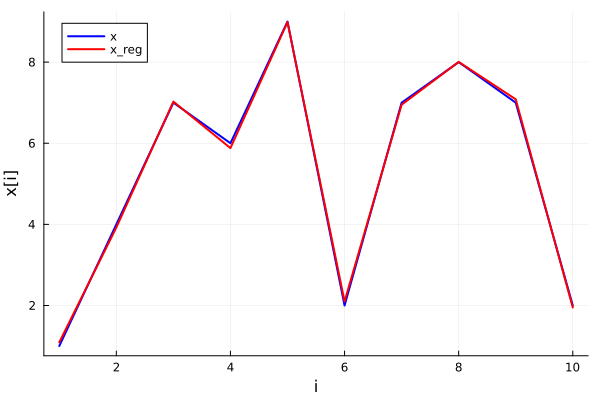

In [9]:
n = 10
k = 5
m = k*n
sigma = 2
q = 10
mu = 0.1

C = zeros(m,n)
for j in 1:n
    row_init = (j - 1) * k + 1
    row_end = j * k
    C[row_init: row_end, j] .= 1
end

r_idx = -q:q
r = exp.(-r_idx.^2 / (sigma^2))
B = zeros(m, m)
for i in 1:m
    for j in 1:m
        if -q <= (i - j) <= q
            r_arr_idx = i - j + q + 1
            B[i, j] = r[r_arr_idx]
        end
    end
end

# A is defined here
A = B * C

x_reg = (A' * A + mu * I(n)) \ (A' * y)
p1 = plot(1:n, x, label="x", lw=2, color="blue")
plot!(p1, 1:n, x_reg, label="x_reg", lw=2, color="red")
xlabel!(p1, "i")
ylabel!(p1, "x[i]")

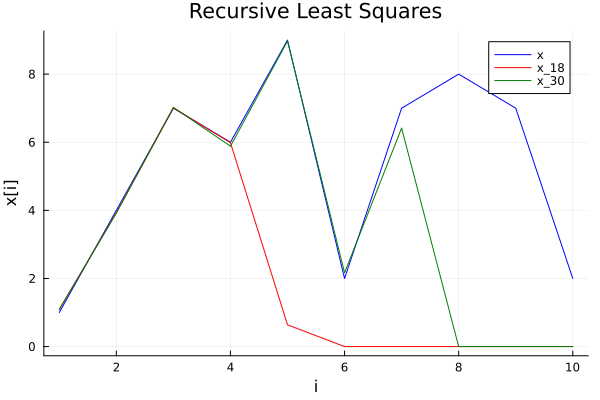

In [10]:
function recursive_ls(A, y, mu)
    m, n = size(A)
    P = mu * I(n) # P(0)
    q = zeros(n) # q(0)
    x_18 = zeros(n)
    x_30 = zeros(n)
    for i in 1:m
        a_i = A[i, :]
        y_i = y[i]
        P = P + a_i * a_i'
        q = q + y_i * a_i
        if i == 18
            x_18 = P \ q
        elseif i == 30
            x_30 = P \ q
        end
    end
    return x_18, x_30
end

x_18, x_30 = recursive_ls(A, y, mu)
plot_e = plot(1:n, x, label="x", color="blue")
plot!(plot_e, 1:n, x_18, label="x_18", color="red")
plot!(plot_e, 1:n, x_30, label="x_30", color="green")
xlabel!(plot_e, "i")
ylabel!(plot_e, "x[i]")
title!(plot_e, "Recursive Least Squares")

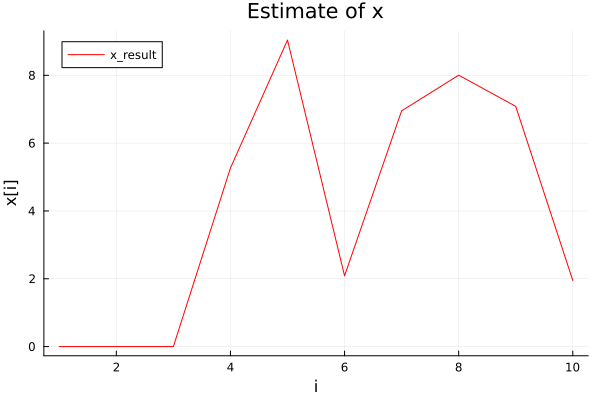

In [27]:
function recursed_to_k(A, y, mu, k)
    m, n = size(A)
    P = mu * I(n) # P(0)
    q = zeros(n) # q(0)
    for i in 1:k
        a_i = A[i, :]
        y_i = y[i]
        P = P + a_i * a_i'
        q = q + y_i * a_i
    end
    return P, q
end

P_m, q_m = recursed_to_k(A, y, mu, m)

function remove(A, y, P_m, q_m)
    m, n = size(A)
    P_remove = zeros(n, n)
    q_remove = zeros(n)
    for i in 1:20
        a_i = A[i, :]
        y_i = y[i]
        P_remove = P_remove + a_i * a_i'
        q_remove = q_remove + y_i * a_i
    end
    P_new = P_m - P_remove
    q_new = q_m - q_remove
    x_result = P_new \ q_new
    return x_result
end

x_result = remove(A, y, P_m, q_m)

plot_f = plot(1:n, x_result, label="x_result", color="red")
xlabel!(plot_f, "i")
ylabel!(plot_f, "x[i]")
title!(plot_f, "Estimate of x")

In [ ]:
fleet_mod_data = readclassjson("fleet_mod_data.json")

K = 10
X = [fleet_mod_data["X$i"] for i in 1:K]
y = [fleet_mod_data["y$i"] for i in 1:K]
n = size(X[1], 1)
T = size(X[1], 2)
N = T*K
A = zeros(N, n+K)
y_vec = vcat([y_k' for y_k in y]...)

for k in 1:K
    row_init = (k - 1) * T + 1
    row_end = k * T
    A[row_init:row_end, 1:n] = X[k]
    A[row_init:row_end, n+k] = 1
end
alpha = A \ y_vec

print(alpha)

LoadError: DimensionMismatch: tried to assign 5×100 array to 100×5 destination